In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [11]:
blind = False

all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
map3_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-map3-all.txt', to_mcsamples=True, blind=blind)
twpt_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=blind)
#twpt_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=blind)
auto_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=blind)
auto_334_344_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-simdv-joint-2pt-moped-run-8arcmincut-december/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x600 with 0 Axes>

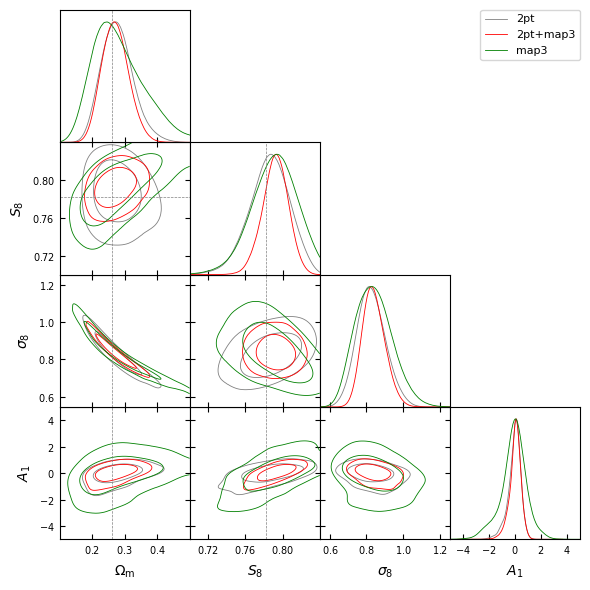

In [19]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twpt_all_sims, all_sims, map3_all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', '2pt+map3', 'map3'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'green'], markers={'om':0.26, 's8':0.782})
#plt.show()
plt.savefig("December5_map3_2pt_plot_more_params.pdf")

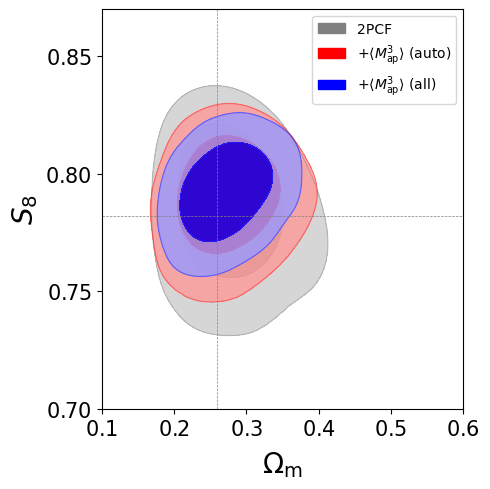

In [18]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, auto_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)',  
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
g.export("December5_map3_2pt_plot.pdf")

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twpt_all_sims, twpt_all_sims_400, all_sims, all_sims_400], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=[r'$\xi_{\pm}$ (500 sims)', r'$\xi_{\pm}$ (400 sims)',r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (500 sims)', r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (400 sims)'], legend_loc='upper right', 
    contour_colors=['blue', 'blue', 'green', 'green'], ls=['-', '--', '-', '--'], markers={'om':0.26, 's8':0.782})
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopt_meas, all_sims, map3_all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', '2pt+map3', 'map3'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'green'], markers={'om':0.26, 's8':0.782})
#plt.savefig("Oct30_sim_analysis_cosmogridcutcov.pdf")
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopt_meas, twpt_all_sims, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt(meas)', '2pt(theo)', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['gray', 'blue', 'red'])
#plt.savefig("Oct30_sim_analysis_cosmogridcutcov.pdf")
plt.show()

In [ ]:
#load covariances w/ 500 sims and 400 sims
from astropy.io import fits

cov500 = fits.open("../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits")
cov400 = fits.open("../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.fits")

mycov500 = cov500[1].data[400:,:][:,400:]
mycov400 = cov400[1].data[400:,:][:,400:]

corr400 = mycov400 / np.sqrt(np.outer(np.diag(mycov400), np.diag(mycov400)))
corr500 = mycov500 / np.sqrt(np.outer(np.diag(mycov500), np.diag(mycov500)))

# Compute the Frobenius norm difference
frobenius_diff = np.linalg.norm(mycov400 - mycov500, 'fro')
print(frobenius_diff)

# Create a combined matrix with upper triangle from corr500 and lower triangle from corr400
combined_corr = np.tril(corr500) + np.triu(corr400, k=1)
#combined_corr = np.tril(corr500)
# Plot the combined correlation matrix
fig, ax = plt.subplots(figsize=(8, 8))
#cax = ax.matshow(combined_corr, cmap='coolwarm')

cax = ax.imshow(combined_corr, cmap='coolwarm', origin='lower')

for v in range(20):
    ax.axhline(v*4, color='k', lw=0.1)
    ax.axvline(v*4, color='k', lw=0.1)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            labels.append(f'{i+1}{j+1}{k+1}')
ax.set_xticks(4*np.arange(20)+2, labels, rotation=90)
ax.set_yticks(4*np.arange(20)+2, labels)

plt.colorbar(cax)

# Add titles and Frobenius norm difference annotation
#ax.set_title("Combined Correlation Matrix\nUpper: mycov500, Lower: mycov400", pad=20)
plt.show()
#plt.savefig("../plots/combined_corr_upper500sims_lower400sims.pdf", dpi=500)

In [ ]:
#Compute the signal-to-noise: total and per bin

def total_signal_to_noise(data_vector, covariance_matrix):
    """Computes the total signal-to-noise ratio for the full data vector and covariance matrix."""
    inv_cov = np.linalg.inv(covariance_matrix)
    sn_total_squared = data_vector.T @ inv_cov @ data_vector
    return np.sqrt(sn_total_squared)

def sectionwise_signal_to_noise(data_vector, covariance_matrix, section_size=4):
    """Computes the signal-to-noise ratio for each section of the data vector and covariance matrix."""
    num_sections = len(data_vector) // section_size
    sn_sections = []
    
    for i in range(num_sections):
        start_idx = i * section_size
        end_idx = start_idx + section_size
        
        data_section = data_vector[start_idx:end_idx]
        cov_section = covariance_matrix[start_idx:end_idx, start_idx:end_idx]
        
        inv_cov_section = np.linalg.inv(cov_section)
        sn_section_squared = data_section.T @ inv_cov_section @ data_section
        sn_sections.append(np.sqrt(sn_section_squared))
    
    return sn_sections

In [ ]:
def modified_signal_to_noise(data_vector, covariance_matrix):
    """Computes the signal-to-noise ratio after removing the first element of each 4-element sequence."""
    # Indices to keep (i.e., remove 0, 4, 8, 12, ..., 76)
    indices_to_keep = [i for i in range(len(data_vector)) if i % 4 != 0]
    
    # Reduced data vector and covariance matrix
    reduced_data_vector = data_vector[indices_to_keep]
    reduced_covariance_matrix = covariance_matrix[np.ix_(indices_to_keep, indices_to_keep)]
    
    # Compute S/N
    inv_reduced_cov = np.linalg.inv(reduced_covariance_matrix)
    sn_squared = reduced_data_vector.T @ inv_reduced_cov @ reduced_data_vector
    return np.sqrt(sn_squared)

def smallscale_signal_to_noise(data_vector, covariance_matrix):
    
    indices_to_keep = [i for i in range(len(data_vector)) if i % 4 == 0]
    reduced_data_vector = data_vector[indices_to_keep]
    reduced_covariance_matrix = covariance_matrix[np.ix_(indices_to_keep, indices_to_keep)]
    inv_reduced_cov = np.linalg.inv(reduced_covariance_matrix)
    sn_squared = reduced_data_vector.T @ inv_reduced_cov @ reduced_data_vector
    return np.sqrt(sn_squared)

In [ ]:
from astropy.io import fits

my_cov_data_file = fits.open('../data/dv/sim_map3-desy3c_cosmogridcutcov.fits')
my_cov_data_file_2 = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')
my_sim_data_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-nocut-b.fits')
my_avg_data_file = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits') #avg data with no cut
my_sim_data_file_2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-5arcmincut.fits') #with 5arcmin cut
my_sim_data_file_6arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-6arcmincut.fits') #with 6arcmin cut
my_sim_data_file_8arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-8arcmincut.fits') #with 8arcmin cut
my_sim_data_file_3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-11arcmincut.fits') #with 11arcmin cut

my_sim_data_file_tent = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-1Nov24-6arcmincut-tentativemap3v.fits')
my_sim_data_file_tent2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-2Nov24-8arcmincut-tentativemap3v2.fits')
my_sim_data_file_tent3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-2Nov24-8arcmincut-tentativemap3v3.fits')

my_sim_data_file_8arcmin_cmg = fits.open('../data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits')

#my_sim_data = my_sim_data_file[1].data #sim data with no cut
#my_sim_data = my_avg_data_file[1].data #avg data with no cut
#my_sim_data = my_sim_data_file_2[1].data #sim data 5arcmin cut
#my_sim_data = my_sim_data_file_6arcmin[1].data #sim data 6arcmin cut
#my_sim_data = my_sim_data_file_8arcmin[1].data #sim data 8arcmin cut
#my_sim_data = my_sim_data_file_3[1].data #sim data 11arcmin cut
#my_sim_data = np.load("../data/dv/map3_average_5arcmincut_maxn100.npy") #avg data with 5arcmin cut

#my_sim_data = my_sim_data_file_tent[1].data #sim data 6arcmin cut and 9,17,28,43 map3 vals
#my_sim_data = my_sim_data_file_tent2[1].data #sim data 8arcmin cut and 8,16,28,45 map3 vals
#my_sim_data = my_sim_data_file_tent3[1].data #sim data 8arcmin cut and 6,12,24,40 map3 vals

my_sim_data = my_sim_data_file_8arcmin_cmg[1].data #sim data 8arcmin cut at cosmogrid cosmology

#my_cut_cov = my_cov_data_file[2].data #cov with 11arcmin scalecut
my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_maxn100.npy") #cov with 8 arcmin scalecut
#my_cut_cov = np.load("../data/covariance/map3_covariance_6arcmincut_maxn100.npy") #cov with 6 arcmin scalecut
#my_cut_cov = np.load("../data/covariance/map3_covariance_5arcmincut_maxn100.npy") #cov with 5arcmin scalecut
#my_cut_cov = my_cov_data_file_2[2].data #cov with no scalecut

#my_cut_cov = np.load("../data/covariance/map3_covariance_6arcmincut_tentativemap3v.npy") #cov with 6arcmin cut and 9,17,28,43 map3 vals
#my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_tentativemap3v2.npy") #cov with 8arcmin cut and 8,16,28,45 map3 vals
#my_cut_cov = np.load("../data/covariance/map3_covariance_8arcmincut_tentativemap3v3.npy") #cov with 8arcmin cut and 6,12,24,40 map3 vals

data_tot = np.zeros(80)
for i in range(80):
    data_tot[i] = my_sim_data[i][6]
#data_tot = my_sim_data
cov_tot = np.array(my_cut_cov)

In [ ]:
print(my_sim_data)

In [ ]:
print(total_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(modified_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(smallscale_signal_to_noise(data_tot,cov_tot))

In [ ]:
print(sectionwise_signal_to_noise(data_tot,cov_tot))

In [ ]:
#Compare plots of sim data with different cuts
def plot_data_vector_sections(data_vectors, covariance_matrices, section_index):
    """Plots the specified section of each data vector with error bars, labeled by redshift bin combination.
    
    Args:
        data_vectors (list of np.ndarray): List of data vectors.
        covariance_matrices (list of np.ndarray): List of covariance matrices.
        section_index (int): Index specifying which section (0 to 19) to plot.
    """
    # Validate inputs
    assert 0 <= section_index < 20, "section_index must be between 0 and 19."
    assert len(data_vectors) == len(covariance_matrices), "Data vectors and covariance matrices must have the same length."

    # Define the redshift bin combinations
    redshift_bins = [
        "111", "112", "113", "114", "122", "123", "124", "133", "134", "144",
        "222", "223", "224", "233", "234", "244", "333", "334", "344", "444"
    ]
    
    # Define the x-axis values and small shifts for visualization
    x_nominal = np.array([7, 14, 25, 40])  # Nominal x-axis values in arcminutes
    shift_values = np.linspace(-0.8, 0.8, len(data_vectors))  # Small shifts for each line

    # Plotting each data vector section with error bars
    plt.figure(figsize=(10, 6))
    
    for i, (data_vector, covariance_matrix) in enumerate(zip(data_vectors, covariance_matrices)):
        # Extract the specified section of the data vector and covariance matrix
        start_idx = section_index * 4
        end_idx = start_idx + 4
        data_section = data_vector[start_idx:end_idx]
        cov_section = covariance_matrix[start_idx:end_idx, start_idx:end_idx]

        # Compute errors as the square root of the diagonal of the covariance matrix section
        errors = np.sqrt(np.diag(cov_section))

        # Apply a small shift to the x-axis values
        x_shifted = x_nominal + shift_values[i]

        # Plot with error bars
        plt.errorbar(x_shifted, x_nominal**4*data_section, yerr=x_nominal**4*errors, fmt='o', label=f'Data Vector {i+1}')
    
    # Labeling
    #plt.yscale("log")
    plt.xlabel(r'$\theta$ (arcminutes)')
    plt.ylabel(r'$\theta^4 \times M_{ap}^3(\theta)$')
    plt.title(f'Redshift Bin Combination {redshift_bins[section_index]} of Data Vectors')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
my_cov_data_file = fits.open('../data/dv/sim_map3-desy3c_cosmogridcutcov.fits')
my_cov_data_file_2 = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')
my_sim_data_file = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-nocut-b.fits')
my_avg_data_file = fits.open('../data/dv/meas_map3-ave-cosmogrid_weighted.fits') #avg data with no cut
my_sim_data_file_2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-5arcmincut.fits') #with 5arcmin cut
my_sim_data_file_6arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-6arcmincut.fits') #with 6arcmin cut
my_sim_data_file_8arcmin = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-8arcmincut.fits') #with 8arcmin cut
my_sim_data_file_3 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoDESY3-30Oct24-11arcmincut.fits') #with 11arcmin cut

my_sim_data0 = my_sim_data_file[1].data #sim data with no cut
my_sim_data5 = my_sim_data_file_2[1].data #sim data 5arcmin cut
my_sim_data6 = my_sim_data_file_6arcmin[1].data #sim data 6arcmin cut
my_sim_data8 = my_sim_data_file_8arcmin[1].data #sim data 8arcmin cut
my_sim_data11 = my_sim_data_file_3[1].data #sim data 11arcmin cut
my_sim_data_AVG = my_avg_data_file[1].data #avg data

my_cut_cov11 = my_cov_data_file[2].data #cov with 11arcmin scalecut
my_cut_cov8 = np.load("../data/covariance/map3_covariance_8arcmincut_maxn100.npy") #cov with 8 arcmin scalecut
my_cut_cov6 = np.load("../data/covariance/map3_covariance_6arcmincut_maxn100.npy") #cov with 6 arcmin scalecut
my_cut_cov5 = np.load("../data/covariance/map3_covariance_5arcmincut_maxn100.npy") #cov with 5arcmin scalecut
my_cut_cov0 = my_cov_data_file_2[2].data #cov with no scalecut

data_tot0 = np.zeros(80)
data_tot5 = np.zeros(80)
data_tot6 = np.zeros(80)
data_tot8 = np.zeros(80)
data_tot11 = np.zeros(80)
data_tot_AVG = np.zeros(80)

for i in range(80):
    data_tot0[i] = my_sim_data0[i][6]
    data_tot5[i] = -my_sim_data5[i][6]
    data_tot6[i] = -my_sim_data6[i][6]
    data_tot8[i] = -my_sim_data8[i][6]
    data_tot11[i] = -my_sim_data11[i][6]
    data_tot_AVG[i] = my_sim_data_AVG[i][6]

cov_tot0 = np.array(my_cut_cov0)
cov_tot5 = np.array(my_cut_cov5)
cov_tot6 = np.array(my_cut_cov6)
cov_tot8 = np.array(my_cut_cov8)
cov_tot11 = np.array(my_cut_cov11)

data_arr = [data_tot0, data_tot5, data_tot6, data_tot8, data_tot11]
cov_arr = [cov_tot0, cov_tot5, cov_tot6, cov_tot8, cov_tot11]
plot_data_vector_sections(data_arr, cov_arr, 19)

In [ ]:
data_arr = [data_tot0, data_tot_AVG]
cov_arr = [cov_tot0, cov_tot0]
plot_data_vector_sections(data_arr, cov_arr, 15)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([twopoint_wCDM, map3_wCDM, all_sims_wCDM], ['om', 's8', 'w0'], filled=False, \
    legend_labels=['2pt only', 'map3 only', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['green', 'red', 'blue'])
plt.show()

In [14]:
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['om', 's8'])
joint_fom = utils.FoM_from_samples_names(all_sims, ['om', 's8'])

print(fom_2pt, joint_fom)
print(joint_fom/fom_2pt)

949.9595911307438 1824.983741639226
1.921117233488779


In [ ]:
def covmatparams(mcchain, index=0.5):#manual check of the det(cov)
    # Assuming twpt_all_sims contains samples and weights is the corresponding weight array
    omega_m_samples = mcchain['om']
    sigma_8_samples = mcchain['sig8']*(mcchain['om']/0.3)**index
    weights = mcchain.weights

    # Step 1: Calculate the weighted mean for each parameter
    mean_omega_m = np.sum(weights * omega_m_samples) / np.sum(weights)
    mean_sigma_8 = np.sum(weights * sigma_8_samples) / np.sum(weights)

    # Step 2: Calculate deviations from the weighted mean
    delta_omega_m = omega_m_samples - mean_omega_m
    delta_sigma_8 = sigma_8_samples - mean_sigma_8

    # Step 3: Calculate the weighted covariance elements
    cov_omega_m_omega_m = np.sum(weights * delta_omega_m * delta_omega_m) / np.sum(weights)
    cov_sigma_8_sigma_8 = np.sum(weights * delta_sigma_8 * delta_sigma_8) / np.sum(weights)
    cov_omega_m_sigma_8 = np.sum(weights * delta_omega_m * delta_sigma_8) / np.sum(weights)

    # Step 4: Construct the 2x2 weighted covariance matrix
    weighted_cov_matrix = np.array([[cov_omega_m_omega_m, cov_omega_m_sigma_8],
                                [cov_omega_m_sigma_8, cov_sigma_8_sigma_8]])

    #print("Weighted 2x2 Covariance Matrix:")
    #print(weighted_cov_matrix)
    #print(np.linalg.det(weighted_cov_matrix))
    #print(1/(np.sqrt(np.linalg.det(weighted_cov_matrix))))
    return(1/(np.sqrt(np.linalg.det(weighted_cov_matrix))))

In [ ]:
def covmap_improv(mcchain1, mcchain2, index=0.5):
    fom1 = covmatparams(mcchain1, index)
    fom2 = covmatparams(mcchain2, index)
    return(fom2/fom1)

In [ ]:
covmatparams(twpt_all_sims)
covmatparams(twpt_all_sims_400)
covmatparams(all_sims)
covmatparams(all_sims_400)

In [ ]:
fom_2pt = utils.FoM_from_samples_names(twpt_all_sims, ['s8'])
joint_fom = utils.FoM_from_samples_names(all_sims, ['s8'])

fom_2pt_400 = utils.FoM_from_samples_names(twpt_all_sims_400, ['s8'])
joint_fom_400 = utils.FoM_from_samples_names(all_sims_400, ['s8'])

print(fom_2pt)
print(joint_fom)
print(fom_2pt_400)
print(joint_fom_400)

In [ ]:
# Get parameter names
param_names_all_sims = all_sims.getParamNames().names  # Correctly get the list of parameter names as strings

# Marginalized means
mean_all_sims = all_sims.getMeans()

# Marginalized standard deviations (uncertainties)
sigma_all_sims = [all_sims.std([param]) for param in param_names_all_sims]

# Repeat for the other chains
param_names_map3_all_sims = map3_all_sims.getParamNames().names
mean_map3_all_sims = map3_all_sims.getMeans()
sigma_map3_all_sims = [map3_all_sims.std([param]) for param in param_names_map3_all_sims]

param_names_twpt_all_sims = twpt_all_sims.getParamNames().names
mean_twpt_all_sims = twpt_all_sims.getMeans()
sigma_twpt_all_sims = [twpt_all_sims.std([param]) for param in param_names_twpt_all_sims]

# Print the marginalized means and uncertainties
print("Marginalized Means and Uncertainties for all_sims:")
for param, mean, sigma in zip(param_names_all_sims, mean_all_sims, sigma_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for map3_all_sims:")
for param, mean, sigma in zip(param_names_map3_all_sims, mean_map3_all_sims, sigma_map3_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

print("\nMarginalized Means and Uncertainties for twpt_all_sims:")
for param, mean, sigma in zip(param_names_twpt_all_sims, mean_twpt_all_sims, sigma_twpt_all_sims):
    print(f"{param}: {float(mean):.4f} ± {float(sigma):.4f}")

In [ ]:
# Define the parameters you're interested in
params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'w0']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = twopoint_wCDM.confidence(param, 0.16, upper=False)
    v2 = twopoint_wCDM.confidence(param, 0.16, upper=True)
    
    # Compute the peak (mean)
    peak = twopoint_wCDM.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8], markers={'om': 0.26, 's8':0.782})
g.add_legend(['2PCF', 'joint (auto)', 'joint (auto+334+344)', 'joint (all)'], legend_loc='upper right')
#plt.savefig("../plots/all_500_sims_dv_results.png")
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
g.export('../plots/contour2d_cosmogrid_dv_and_cov_19Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims_update, auto_all_sims, auto_334_344_all_sims, all_sims], 'om', 's8', filled=True, 
    colors=['gray','red', 'green', 'blue'], alphas=[0.8,0.8, 0.8,0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twpt_all_sims, twpt_all_sims_update], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['2PCF (analytic cov)','2PCF (updated)'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([desy3_dm, desy3_baryon], 'om', 's8', filled=True, 
    colors=['green','red'], alphas=[0.8,0.8])
g.add_legend(['dm','baryon'], legend_loc='upper right', fontsize=10)
g.add_x_marker(0.26)
g.add_y_marker(0.782)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
#g.export('../plots/contour2d_cosmogrid_dv_and_cov_5Sep24.pdf')

In [ ]:
# Define the parameters you're interested in
params = ['om', 's8', 'h0', 'cosmological_parameters--n_s', 'cosmological_parameters--omega_b', 'cosmological_parameters--mnu', 'w0']

for param in params:
    # Get quantiles for the parameter (68% confidence interval)
    v1 = desy3_baryon.confidence(param, 0.16, upper=False)
    v2 = desy3_baryon.confidence(param, 0.16, upper=True)
    
    # Compute the peak (mean)
    peak = desy3_baryon.getMeans()
    
    print(f"Parameter: {param}")
    print(f"Peak: {peak}")
    print(f"1-sigma Lower: {v1}")
    print(f"1-sigma Upper: {v2}")

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([twopoint_wCDM, all_sims_wCDM], 's8', 'w0', filled=True, 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend([r'2PCF', r'+$\langle M_{\rm ap}^3\rangle$'], legend_loc='upper right')
g.add_x_marker(0.782)
g.add_y_marker(-1.0)
#plt.suptitle(r'$w$CDM', y=1.02, x = 0.59, fontsize=14)
plt.savefig('../plots/wCDM_contour2d_cosmogrid_dv_and_cov_25Sep24.pdf')

In [ ]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data1 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt')
data2 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt')
data3 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt')

data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt')
map3_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt')
twpt_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov.txt')

log_posterior = twpt_data_all[:, -2]
parameters = twpt_data_all[:, :-2]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")

In [ ]:
thpt1 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim1-cosmogrid.fits')
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim2-cosmogrid.fits')
thpt3 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim3-cosmogrid.fits')
thpt_all = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')

thpt_bf_sim1 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim1-BESTFIT.fits')
thpt_bf_sim2 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim2-BESTFIT.fits')
thpt_bf_sim3 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim3-BESTFIT.fits')
thpt_bf_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sims_all-BESTFIT.fits')

thpt_theo = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-theory-cosmogrid-params-Aug15.fits')
thpt_theo_huge_IA = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-theory-cosmogrid-params-huge_IA.fits')
thpt_bf_map3_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-map3-sims_all-BESTFIT.fits')

In [ ]:
line_args = dict(color='g', ls='-')
fig, axes = thpt_all.plot2d(4, 5, figsize=(25, 20), **line_args)
#line_args2 = dict(color='C0', lw=3, ls=':')
#fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args2 = dict(color='r', lw=3, ls='-')
fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args3 = dict(color='b', alpha=0.7, lw=2, ls='-')
fig, axes = thpt_theo_huge_IA.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args3)
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-10,60)
#plt.savefig("../plots/Map3_average_of_cosmogrid_sims_with_theory_and_IA_5Sep24.png")

In [ ]:
from astropy.io import fits
twopt1_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim1-BESTFIT.fits')
twopt2_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim2-BESTFIT.fits')
twopt3_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim3-BESTFIT.fits')
twopt_all_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sims_all-BESTFIT.fits')
twopt_all_2ptbf = fits.open('../data/dv/sim_2pt-NLA-some-sims-2pt-sims_all-BESTFIT.fits')

In [ ]:
twopt1_data = fits.open('../data/dv/meas_2pt-sim1-cosmogrid.fits')
twopt2_data = fits.open('../data/dv/meas_2pt-sim2-cosmogrid.fits')
twopt3_data = fits.open('../data/dv/meas_2pt-sim3-cosmogrid.fits')
twopt_all_data = fits.open('../data/dv/meas_2pt-ave-cosmogrid_weighted.fits')

In [ ]:
def extract_2pt(fitsfile):
    
    xip = fitsfile[2].data
    xim = fitsfile[3].data
    
    out = np.zeros(400)
    for i in range(200):
        out[i] = fitsfile[2].data[i][3]
        out[i+200] = fitsfile[3].data[i][3]
        
    return(out)

In [ ]:
def transform_data(datav):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    transformed_data = np.dot(transf_moped.T, datav)
    return(transformed_data)

def transform_cov(covm):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    newtransf = np.zeros(shape=(307,96))
    print(np.shape(newtransf[:227,:][:,:16]))
    newtransf[:227,:][:,:16] = transf_moped
    newtransf[227:,:][:,16:] = np.eye(80)
    transformed_cov = np.dot(newtransf.T, np.dot(covm, newtransf))
    return(transformed_cov)

In [ ]:
scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])

In [ ]:
scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))

In [ ]:
scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))

In [ ]:
def scale_cut_2pt(vector):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    return (np.delete(vector, scale_cuts_all))

In [ ]:
def scale_cut_2pt_cov(matrix):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    matrix = np.delete(matrix, scale_cuts_all, axis=0)
    matrix = np.delete(matrix, scale_cuts_all, axis=1)
    return (matrix)

In [ ]:
from astropy.io import fits
to_cov = fits.open("../data/covariance/cov_xip_xim_map3.fits")
cov_all_nocut = to_cov[1].data
cov_all = transform_cov(scale_cut_2pt_cov(cov_all_nocut))

In [ ]:
twpt1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_data)))
twpt2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_data)))
twpt3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_data)))
twpt_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_data)))

twpt_bf_sim1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_file)))
twpt_bf_sim2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_file)))
twpt_bf_sim3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_file)))
twpt_bf_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_file)))

twpt_bf_only = transform_data(scale_cut_2pt(extract_2pt(twopt_all_2ptbf)))

In [ ]:
dados1 = np.concatenate((twpt1,thpt1.get_signal()))
dados2 = np.concatenate((twpt2,thpt2.get_signal()))
dados3 = np.concatenate((twpt3,thpt3.get_signal()))
dados_all = np.concatenate((twpt_all,thpt_all.get_signal()))

teoria1 = np.concatenate((twpt_bf_sim1,thpt_bf_sim1.get_signal()))
teoria2 = np.concatenate((twpt_bf_sim2,thpt_bf_sim2.get_signal()))
teoria3 = np.concatenate((twpt_bf_sim3,thpt_bf_sim3.get_signal()))
teoria_all = np.concatenate((twpt_bf_all,thpt_bf_all.get_signal()))

In [ ]:
minus_file = fits.open('../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0.fits')
minus_file.info()
dataminus = minus_file[1].data
print(dataminus)
for i in range(len(dataminus)):
    dataminus[i][6] = -1*dataminus[i][6]

plus_file = minus_file
plus_file[1].data = dataminus
#output_path = '../data/dv/altered_sign_sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits'
#plus_file.writeto(output_path, overwrite=False)

In [ ]:
plus_file = fits.open('../data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0-emulated.fits')
plus_file.info()
dataplus = plus_file[1].data
print(dataplus)

In [ ]:
theory_mnu009 = threepoint.ThreePointDataClass.from_fits('../data/dv/altered_sign_sim_map3-NLA-cosmoCosmoG-mnutest0.fits')
thmnu_009 = -1*theory_mnu009.get_signal()
thmnu_006 = thpt_theo.get_signal()
datamap3 = thpt_all.get_signal()

In [ ]:
diff_mnu006 = datamap3 - thmnu_006
diff_mnu009 = datamap3 - thmnu_009

numm = (500-diff_mnu006.size-2)/(500-1)
invcovar = np.linalg.inv(cov_all[16:,:][:,16:]) * numm
chi2mnu006 = diff_mnu006.dot(invcovar).dot(diff_mnu006)
dofmnu006  = diff_mnu006.size
print('{:.3f}/{}={:.3f}'.format(chi2mnu006, dofmnu006, chi2mnu006/dofmnu006))
chi2mnu009 = diff_mnu009.dot(invcovar).dot(diff_mnu009)
dofmnu009  = diff_mnu009.size
print('{:.3f}/{}={:.3f}'.format(chi2mnu009, dofmnu009, chi2mnu009/dofmnu009))

In [ ]:
line_args = dict(color='g', ls='-')
fig, axes = thpt_all.plot2d(4, 5, figsize=(25, 20), **line_args)
line_args2 = dict(color='r', lw=3, ls='-')
fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args3 = dict(color='b', alpha=0.7, lw=2, ls='-')
fig, axes = theory_mnu009.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args3)
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-10,60)
plt.show()

In [ ]:
dife1 = dados1 - teoria1
dife2 = dados2 - teoria2
dife3 = dados3 - teoria3
dife_all = dados_all - teoria_all

f = (500-dife1.size-2)/(500-1)
icov_all = np.linalg.inv(cov_all) * f

chi21 = dife1.dot(icov_all).dot(dife1)
dof1  = dife1.size
print('{:.3f}/{}={:.3f}'.format(chi21, dof1, chi21/dof1))

chi22 = dife2.dot(icov_all).dot(dife2)
dof2  = dife2.size
print('{:.3f}/{}={:.3f}'.format(chi22, dof2, chi22/dof2))

chi23 = dife3.dot(icov_all).dot(dife3)
dof3  = dife3.size
print('{:.3f}/{}={:.3f}'.format(chi23, dof3, chi23/dof3))

chi2_all = dife_all.dot(icov_all).dot(dife_all)
dof_all  = dife_all.size
print('{:.3f}/{}={:.3f}'.format(chi2_all, dof_all, chi2_all/dof_all))

In [ ]:
dadosm = thpt_all.get_signal()
teoriam = thpt_bf_map3_all.get_signal()

difem = dadosm - teoriam
cov_allm = to_cov[1].data[400:,:][:,400:]

f = (500-difem.size-2)/(500-1)
icov_allm = np.linalg.inv(cov_allm) * f

chi2m = difem.dot(icov_allm).dot(difem)
dofm  = difem.size
print('{:.3f}/{}={:.3f}'.format(chi2m, dofm, chi2m/dofm))

In [ ]:
dadosx = twpt_all
teoriax = twpt_bf_only

difex = dadosx - teoriax
cov_allx = cov_all[:16,:][:,:16]

f = (500-difex.size-2)/(500-1)
icov_allx = np.linalg.inv(cov_allx) * f

chi2x = difex.dot(icov_allx).dot(difex)
dofx  = difex.size
print('{:.3f}/{}={:.3f}'.format(chi2x, dofx, chi2x/dofx))